In [1]:
import pandas as pd

news = pd.read_csv("../data/news.csv", encoding="latin1", low_memory=False)
stock = pd.read_csv("../data/nifty50.csv", encoding="cp1252")

print("news:", news.shape)
print("stock:", stock.shape)
print(list(news.columns)[:6])
print(list(stock.columns))

news: (3349, 189)
stock: (142, 7)
['Title', 'Date', 'Description', 'Author', 'Content', 'Keywords']
['ï»¿Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ', 'Turnover (â‚¹ Cr)']


In [2]:
news = news.iloc[:, :2]
print(news.shape, list(news.columns))
print(news.isnull().sum())

(3349, 2) ['Title', 'Date']
Title    0
Date     0
dtype: int64


In [3]:
news = news.dropna()
print("after dropna:", news.shape)
news = news.drop_duplicates()
print("after dedupe:", news.shape)
news['Title'] = news['Title'].str.strip()

after dropna: (3349, 2)
after dedupe: (3348, 2)


In [4]:
grouped_news = news.groupby("Date")["Title"].apply(list).reset_index()
print(grouped_news.shape)
print(repr(grouped_news.iloc[0]['Date'])[:120])

(174, 2)
' just some time back that you resisted going to business school. What makes you tick? What are your mantras that are di


In [5]:
grouped_news = grouped_news.iloc[1:]
grouped_news['Date'] = pd.to_datetime(grouped_news['Date'], format='%d-%m-%Y', errors='coerce')
print(grouped_news.shape, "| NaT:", grouped_news['Date'].isna().sum())
print(grouped_news['Date'].min(), "->", grouped_news['Date'].max())
grouped_news.to_csv("../data/grouped_news.csv", index=False)

(173, 2) | NaT: 0
2025-02-07 00:00:00 -> 2025-08-21 00:00:00


In [6]:
stock.columns = ['date','open','high','low','close','shares_traded','turnover_cr']
stock['shares_traded'] = stock['shares_traded'].astype(float)
stock['date'] = pd.to_datetime(stock['date'], format='%d-%b-%Y', errors='coerce')
print(stock.shape, "| NaT:", stock['date'].isna().sum())
print(stock['date'].min(), "->", stock['date'].max())

(142, 7) | NaT: 0
2025-02-01 00:00:00 -> 2025-08-29 00:00:00


In [7]:
merged = pd.merge(stock, grouped_news, left_on='date', right_on='Date', how='inner')
print("MERGED:", merged.shape)
print("nulls:", merged.isnull().sum().sum())
print("headlines/day — mean %.1f, min %d, max %d" % (
    merged['Title'].apply(len).mean(),
    merged['Title'].apply(len).min(),
    merged['Title'].apply(len).max()))

MERGED: (132, 9)
nulls: 0
headlines/day — mean 24.7, min 2, max 75


### Data integrity check — no silent loss

3,349 raw headlines → 3,348 after dedup (1 exact duplicate) → 173 unique dates (Feb 7 – Aug 21, after dropping 1 malformed row where article text had spilled into the Date column) → inner-joined with 142 NIFTY50 trading days (Feb 1 – Aug 29) → **132 rows**.

The dropped stock days are weekends/holidays plus the Feb 1–6 and Aug 22–29 windows where the news feed has no coverage. Both date columns parsed with 0 `NaT` values, and the merged frame has 0 nulls.

In [8]:
merged['movement'] = merged['close'] - merged['open']
merged['target'] = (merged['movement'] > 0).astype(int)
print(merged['target'].value_counts())

target
0    67
1    65
Name: count, dtype: int64


In [9]:
positive_words = [
    'gain', 'gains', 'gained', 'gainers', 'gainer',
    'growth', 'grew', 'grow', 'growing',
    'profit', 'profitable', 'profitability', 'profits',
    'rise', 'rises', 'rising', 'risen', 'rose',
    'rally', 'rallied', 'rallying', 'rallies',
    'surge', 'surges', 'surged', 'surging',
    'jump', 'jumps', 'jumped', 'jumping',
    'soar', 'soars', 'soared', 'soaring',
    'climb', 'climbs', 'climbed', 'climbing',
    'advance', 'advances', 'advanced', 'advancing',
    'recover', 'recovery', 'recovered', 'recovering', 'recovers',
    'rebound', 'rebounds', 'rebounded', 'rebounding',
    'upturn', 'upswing', 'uptrend', 'upside',
    'boom', 'booming', 'boomed',
    'bullish', 'bull', 'bull run',
    'outperform', 'outperforms', 'outperformed', 'outperforming',
    'beat', 'beats', 'beaten',
    'exceed', 'exceeds', 'exceeded', 'exceeding',
    'strong', 'stronger', 'strongest', 'strengthen', 'strengthens',
    'robust', 'resilient', 'resilience',
    'positive', 'positively',
    'optimism', 'optimistic', 'optimist',
    'confidence', 'confident',
    'momentum', 'accelerate', 'accelerating', 'acceleration',
    'record', 'record-high', 'all-time high', 'peak', 'peaked',
    'high', 'highs', 'higher', 'highest',
    'milestone', 'breakthrough',
    'expand', 'expansion', 'expands', 'expanded', 'expanding',
    'upgrade', 'upgraded', 'upgrades',
    'buy', 'buying',
    'invest', 'investment', 'investing', 'investor', 'investors',
    'inflow', 'inflows',
    'net profit', 'net sales', 'revenue',

    'earnings', 'earning',
    'dividend', 'dividends',
    'bonus', 'windfall',
    'order win', 'order book', 'order inflow',
    'contract win', 'new contract',
    'acquisition', 'merger', 'deal',
    'partnership', 'collaboration', 'agreement',
    'launch', 'launches', 'launched', 'launching',
    'nod', 'approval', 'approved', 'approve',
    'clearance', 'cleared',
    'listing', 'listed', 'debut',
    'ipo', 'initial public offering',
    'fdi', 'foreign investment',
    'fund inflow',
    'target', 'price target',
    'recommendation', 'recommend',
    'bullish outlook', 'positive outlook',
    'ebitda', 'margin expansion',
    'market share', 'market cap',
    'steady', 'stable', 'stability',
    'demand', 'demand recovery', 'demand growth',
    'consumption', 'consumption growth',
    'export', 'exports', 'export growth',
    'sales growth', 'revenue growth', 'profit growth',
    'year-on-year', 'y-o-y', 'yoy',
    'quarter-on-quarter', 'qoq',
    'multi-year high', '52-week high',
    'all-time', 'historic high',
    'interest rate cut', 'rate cut',
    'fiscal stimulus', 'stimulus',
    'gdp growth', 'economic growth',
    'reform', 'reforms', 'reforming',
    'deregulation', 'liberalisation', 'liberalization',
    'tax relief', 'tax cut', 'tax benefit',
    'subsidy', 'subsidies',
    'infrastructure spend', 'capex',
    'innovation', 'innovate', 'innovative',
    'technology upgrade', 'digital transformation',
    'efficiency', 'efficient',
    'cost savings', 'cost reduction',
    'margin improvement', 'operating leverage',
    'value creation', 'shareholder value',
    'buyback', 'share buyback', 'repurchase',
    'esop', 'stock options',
    'accretive', 'value accretive',
    'synergy', 'synergies',
    'turnaround',
    'green shoot', 'green shoots',
    'soft landing',
    'credit upgrade', 'rating upgrade',
    'debt reduction', 'deleveraging',
    'asset light', 'capital efficient',
    'guidance raised', 'guidance upgrade',
    'estimate beat', 'earnings beat',
    'net interest margin', 'nim improvement',
    'npa reduction', 'asset quality improvement',
    'loan growth', 'credit growth',
    'deposit growth',
    'capacity addition', 'capacity expansion',
    'new plant', 'greenfield', 'brownfield',
    'foray', 'diversification',
    'market leader', 'market leadership',
    'premium', 'premiumisation',
    'high demand', 'strong demand',
    'oversubscribed', 'oversubscription',
    'favourable', 'favorable',
    'tailwind', 'tailwinds',
    'healthy', 'healthier',
    'superior', 'superlative',
    'exceptional', 'excellent',
    'impressive', 'remarkable',
    'notable', 'noteworthy',
    'significant upside', 'upside potential',
    're-rating',
    'value unlocking',
    'listed gains', 'listing gains',
    'multibagger',
    'broad-based rally', 'across-the-board gains',
    'fresh buying', 'accumulate', 'accumulation',
    'long position', 'long buildup',
    'covers', 'short covering',
    'supportive policy', 'policy support',
    'global cues positive', 'positive global cues',
]

negative_words = [
    'loss', 'losses', 'lost', 'lose', 'losing',
    'decline', 'declines', 'declined', 'declining',
    'fall', 'falls', 'fell', 'fallen', 'falling',
    'drop', 'drops', 'dropped', 'dropping',
    'crash', 'crashes', 'crashed', 'crashing',
    'plunge', 'plunges', 'plunged', 'plunging',
    'tumble', 'tumbles', 'tumbled', 'tumbling',
    'slump', 'slumps', 'slumped', 'slumping',
    'slide', 'slides', 'slid', 'sliding',
    'sink', 'sinks', 'sank', 'sunk', 'sinking',
    'dip', 'dips', 'dipped', 'dipping',
    'plummet', 'plummets', 'plummeted', 'plummeting',
    'nosedive', 'nosedived',
    'collapse', 'collapses', 'collapsed', 'collapsing',
    'downturn', 'downswing', 'downtrend', 'downside',
    'bearish', 'bear', 'bear run', 'bear market',
    'underperform', 'underperforms', 'underperformed', 'underperforming',
    'miss', 'misses', 'missed',
    'below estimate', 'below expectations', 'below forecast',
    'weak', 'weaker', 'weakest', 'weaken', 'weakening', 'weakness',
    'fragile', 'vulnerable', 'vulnerability',
    'negative', 'negatively',
    'pessimism', 'pessimistic',
    'concern', 'concerns', 'concerned', 'concerning',
    'worry', 'worries', 'worried', 'worrying',
    'uncertainty', 'uncertain', 'unpredictable',
    'risk', 'risks', 'risky', 'riskier',
    'low', 'lows', 'lower', 'lowest',
    '52-week low', 'multi-year low', 'historic low',
    'all-time low',
    'downgrade', 'downgraded', 'downgrades',
    'sell', 'selling', 'selloff', 'sell-off',
    'outflow', 'outflows', 'fund outflow',
    'net loss', 'net deficit',
    'revenue decline', 'sales decline',
    'profit decline', 'profit fall',
    'margin pressure', 'margin compression', 'margin erosion',
    'earnings miss', 'estimate miss',
    'guidance cut', 'guidance reduced', 'guidance lowered',
    'guidance withdrawn',
    'cost pressure', 'cost inflation', 'input cost',
    'inflation', 'inflationary', 'hyperinflation',
    'recession', 'recessionary',
    'stagflation',
    'slowdown', 'slow growth', 'deceleration',
    'contraction', 'economic contraction',
    'gdp decline', 'gdp contraction',
    'unemployment', 'job cuts', 'layoffs', 'retrenchment',
    'downsizing',
    'tariff', 'tariffs', 'trade war', 'trade tensions',
    'sanctions', 'sanction',
    'ban', 'banned', 'prohibit',
    'regulation', 'regulatory hurdle', 'regulatory risk',
    'investigation', 'probe', 'scrutiny',
    'penalty', 'penalties', 'fine', 'fines',
    'fraud', 'scam', 'scandal',
    'default', 'defaults', 'defaulted', 'defaulting',
    'bankruptcy', 'insolvency', 'insolvent',
    'liquidation', 'liquidate', 'winding up',
    'debt', 'high debt', 'debt burden', 'overleveraged',
    'npa', 'bad loan', 'bad loans', 'non-performing',
    'write-off', 'write-offs',
    'provisioning', 'provisions',
    'credit downgrade', 'rating downgrade',
    'interest rate hike', 'rate hike', 'rate increase',
    'tightening', 'monetary tightening', 'hawkish',
    'currency depreciation', 'rupee fall', 'currency risk',
    'foreign exchange loss', 'forex loss',
    'geopolitical risk', 'geopolitical tension',
    'war', 'conflict', 'tension',
    'supply chain disruption', 'supply shortage',
    'shortage', 'scarcity',
    'demand slump', 'demand weakness', 'weak demand',
    'overcapacity', 'oversupply',
    'inventory build', 'inventory pile',
    'import pressure',
    'competition', 'competitive pressure',
    'market share loss',
    'customer churn',
    'resignation', 'exit', 'step down', 'stepped down',
    'resignation of cfo', 'ceo quits', 'management exit',
    'stake sale', 'promoter selling',
    'dilution', 'equity dilution',
    'block deal loss', 'block deal exit',
    'halt', 'suspension', 'suspended',
    'noc rejected', 'approval denied',
    'order cancellation', 'contract cancellation',
    'project delay', 'delayed',
    'headwinds', 'headwind',
    'adverse', 'adversely',
    'unfavourable', 'unfavorable',
    'caution', 'cautious',
    'underweight',
    'cut', 'cuts', 'price cut',
    'slash', 'slashed', 'slashes',
    'bleed', 'bleeding',
    'erosion',
    'pressure', 'pressured', 'under pressure',
    'drag', 'drags', 'dragged',
    'drag on earnings',
    'loser', 'losers', 'top loser',
    'bottom performer',
    'stress', 'distress', 'financial stress',
    'short position', 'short buildup', 'short selling',
    'circuit breaker', 'lower circuit',
    'sell-on-rise', 'profit booking',
    'unwinding',
    'global cues negative', 'negative global cues',
    'fii selling', 'dii selling', 'institutional selling',
    'correction', 'market correction', 'broad-based selloff',
]

In [10]:
def sentiment_score(text):
    text = str(text).lower()
    score = 0
    for word in positive_words:
        score += text.count(word)
    for word in negative_words:
        score -= text.count(word)
    return score

merged['sentiment_score'] = merged['Title'].apply(sentiment_score)
print(merged['sentiment_score'].describe().round(2))

count    132.00
mean      18.17
std       22.54
min      -24.00
25%        4.00
50%       13.00
75%       31.25
max       88.00
Name: sentiment_score, dtype: float64


In [11]:
print(merged.groupby('target')['sentiment_score'].mean().round(2))
print("correlation:", round(merged['sentiment_score'].corr(merged['movement']), 4))
print((merged['sentiment_score'] <= 0).sum(), "days scored <= 0 out of", len(merged))

target
0    14.81
1    21.63
Name: sentiment_score, dtype: float64
correlation: 0.0943
26 days scored <= 0 out of 132


### What the sentiment scores actually show

Mean sentiment is **21.63** on up days vs **14.81** on down days — a real gap, but the correlation between sentiment score and same-day movement is only **0.094**. That is close to zero. Any signal here is weak.

Four limitations of this scoring approach, found by inspecting the data:

**1. The score is heavily positive-skewed.** Mean +18.17, median +13, and only 26 of 132 days score ≤ 0 — yet the market closed up on just 65 of 132 days (49%). So a `score > 0` rule will predict UP on ~80% of days regardless of what the news says.

**2. `.count()` matches substrings, not words.** The term `'gain'` produces 268 substring hits in the merged corpus but is a standalone word only 117 times. Of the remaining 151, most sit inside other listed terms — 'gains' (59), 'gainer'/'gainers' (77), 'gained' (1) — which double-counts them, and 12 are genuine false positives inside "against" (11) and "bargain" (1). Part C quantifies this across the full vocabulary.

**3. Stem families double-count.** Both `'gain'` and `'gains'` are in the positive list, so the word "gains" scores **+2**, not +1. Same for `'grow'`/`'growth'` and `'loss'`/`'losses'`. This inflates score magnitudes on both sides and directly feeds limitation 1.

**4. The score is unbounded and scales with headline volume.** Days range from 2 to 75 headlines (mean 24.7), so a quiet day cannot produce a large-magnitude score no matter how strong the news. Normalising by headline count would be the obvious fix.

Note also that `merged['Title']` holds a Python *list* of headlines. `str(text)` stringifies the entire list — brackets, quotes and commas included — before scoring. This still works because `.count()` searches substrings, but it means the scorer is not reading clean text.

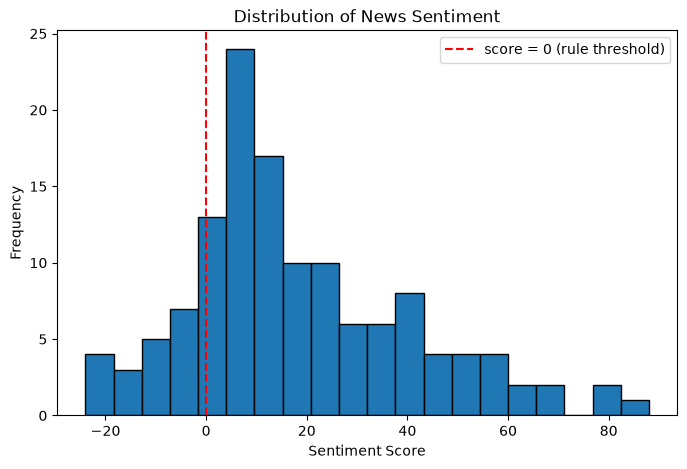

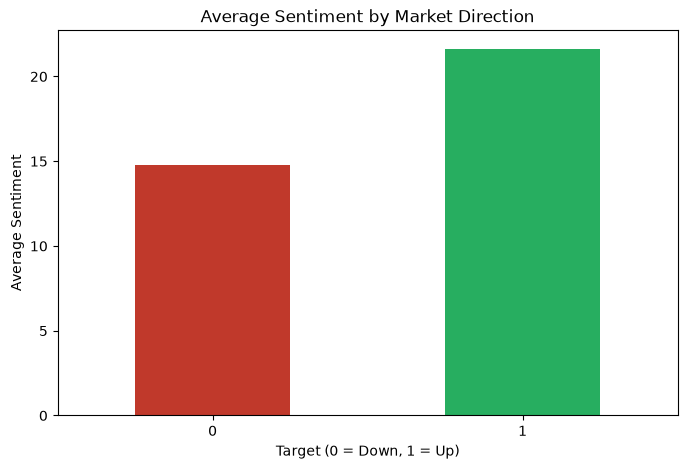

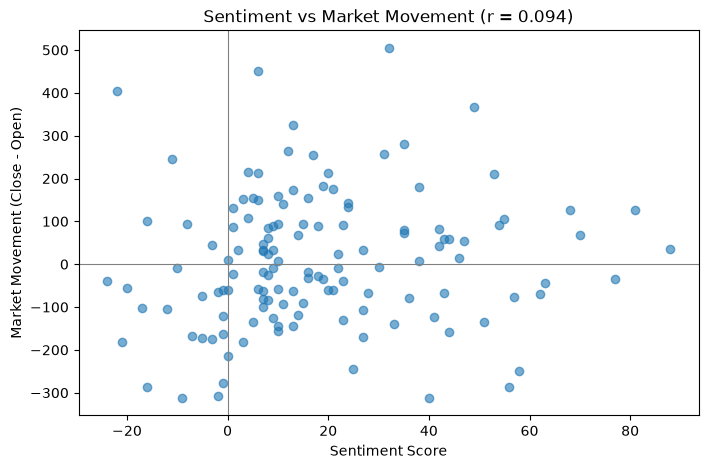

In [12]:
import os
import matplotlib.pyplot as plt
os.makedirs("../plots_mine", exist_ok=True)

plt.figure(figsize=(8,5))
plt.hist(merged['sentiment_score'], bins=20, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='score = 0 (rule threshold)')
plt.xlabel("Sentiment Score"); plt.ylabel("Frequency")
plt.title("Distribution of News Sentiment"); plt.legend()
plt.savefig("../plots_mine/histogram.png", dpi=300, bbox_inches='tight'); plt.show()

plt.figure(figsize=(8,5))
merged.groupby('target')['sentiment_score'].mean().plot(kind='bar', color=['#c0392b','#27ae60'])
plt.xlabel("Target (0 = Down, 1 = Up)"); plt.ylabel("Average Sentiment")
plt.title("Average Sentiment by Market Direction"); plt.xticks(rotation=0)
plt.savefig("../plots_mine/barplot.png", dpi=300, bbox_inches='tight'); plt.show()

plt.figure(figsize=(8,5))
plt.scatter(merged['sentiment_score'], merged['movement'], alpha=0.6)
plt.axhline(0, color='grey', lw=0.8); plt.axvline(0, color='grey', lw=0.8)
plt.xlabel("Sentiment Score"); plt.ylabel("Market Movement (Close - Open)")
plt.title("Sentiment vs Market Movement (r = 0.094)")
plt.savefig("../plots_mine/scatterplot.png", dpi=300, bbox_inches='tight'); plt.show()

In [13]:
def predict_market(score):
    if score > 0: return "UP"
    elif score < 0: return "DOWN"
    else: return "NEUTRAL"

merged['prediction'] = merged['sentiment_score'].apply(predict_market)
merged['prediction_binary'] = (merged['sentiment_score'] > 0).astype(int)
print(merged['prediction'].value_counts())

prediction
UP         106
DOWN        23
NEUTRAL      3
Name: count, dtype: int64


In [14]:
accuracy = (merged['prediction_binary'] == merged['target']).mean()
baseline = (merged['target'] == merged['target'].mode()[0]).mean()
always_up = (merged['target'] == 1).mean()

print("Part A accuracy:      ", round(accuracy*100, 2), "%")
print("Majority baseline:    ", round(baseline*100, 2), "%")
print("Always-predict-UP:    ", round(always_up*100, 2), "%")
print()
print(pd.crosstab(merged['prediction_binary'], merged['target'],
                  rownames=['Predicted'], colnames=['Actual']))

merged.to_csv("../data/final_project_dataset_anmol.csv", index=False)

Part A accuracy:       59.85 %
Majority baseline:     50.76 %
Always-predict-UP:     49.24 %

Actual      0   1
Predicted        
0          20   6
1          47  59


### Part A evaluation

Same-day accuracy **59.85%** vs a majority-class baseline of **50.76%** — a 9-point edge.

However, the crosstab shows this edge is not evenly distributed. The rule predicts UP on 106 of 132 days (80%) and is correct only **56%** of the time when it does. On the 26 days it predicts DOWN, it is correct **77%** of the time. The entire signal lives in the small set of strongly-negative-sentiment days.

Note that `binary_prediction` maps NEUTRAL (score exactly 0, 3 days) to 0 alongside DOWN (23 days), so the 26 "predicted down" days are not all negative-sentiment days.

**Critically, this is not prediction.** Both `sentiment_score` and `target` are computed from the same trading day. A high number here shows same-day co-movement — news and price moving together because they share an underlying cause — not forecasting ability. It could not be traded: you would need today's headlines before today's close. Part B fixes this by shifting the target to the next trading day.

# Part B — Machine Learning Pipeline

Part A measured **same-day co-movement**: sentiment and price were both taken from the same trading day, so a high accuracy there says nothing about forecasting.

Part B fixes this by shifting the target forward one trading day. The question becomes: given everything known as of today's close (today's sentiment, today's price action, recent history), does tomorrow close up or down?

Every model below is compared against a majority-class baseline computed on the same test period.

In [15]:
import numpy as np

ml_df = pd.read_csv("../data/final_project_dataset_anmol.csv", parse_dates=['date'])
ml_df = ml_df.sort_values('date').reset_index(drop=True)
ml_df['next_day_target'] = ml_df['target'].shift(-1)
ml_df = ml_df.dropna(subset=['next_day_target'])
ml_df['next_day_target'] = ml_df['next_day_target'].astype(int)
print(ml_df.shape)

(131, 15)


In [16]:
ml_df['sentiment_ma3']  = ml_df['sentiment_score'].rolling(3).mean()
ml_df['sentiment_ma7']  = ml_df['sentiment_score'].rolling(7).mean()
ml_df['sentiment_std3'] = ml_df['sentiment_score'].rolling(3).std()
ml_df['movement_lag1']  = ml_df['movement'].shift(1)
ml_df['movement_lag2']  = ml_df['movement'].shift(2)
ml_df['volume_change']  = ml_df['shares_traded'].pct_change()
ml_df['high_low_spread'] = (ml_df['high'] - ml_df['low']) / ml_df['open'] * 100

ml_df = ml_df.dropna().reset_index(drop=True)
print(ml_df.shape)
print(ml_df['next_day_target'].value_counts())

(125, 22)
next_day_target
1    64
0    61
Name: count, dtype: int64


In [17]:
feature_cols = ['sentiment_score','sentiment_ma3','sentiment_ma7','sentiment_std3',
                'movement_lag1','movement_lag2','volume_change','high_low_spread']
X = ml_df[feature_cols]
y = ml_df['next_day_target']

split_idx = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} days ({ml_df['date'].iloc[0].date()} → {ml_df['date'].iloc[split_idx-1].date()})")
print(f"Test:  {len(X_test)} days ({ml_df['date'].iloc[split_idx].date()} → {ml_df['date'].iloc[-1].date()})")

Train: 100 days (2025-02-17 → 2025-07-15)
Test:  25 days (2025-07-16 → 2025-08-20)


In [18]:
majority_baseline = (y_test == y_test.mode()[0]).mean()
print("Majority-class baseline (test period):", round(majority_baseline*100, 2), "%")
print(y_test.value_counts())

Majority-class baseline (test period): 56.0 %
next_day_target
0    14
1    11
Name: count, dtype: int64


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression accuracy:", round(accuracy_score(y_test, y_pred_lr)*100, 2), "%")
print(classification_report(y_test, y_pred_lr, target_names=['Down','Up'], zero_division=0))

Logistic Regression accuracy: 44.0 %
              precision    recall  f1-score   support

        Down       0.50      0.43      0.46        14
          Up       0.38      0.45      0.42        11

    accuracy                           0.44        25
   macro avg       0.44      0.44      0.44        25
weighted avg       0.45      0.44      0.44        25



In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=10,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest accuracy:", round(accuracy_score(y_test, y_pred_rf)*100, 2), "%")
print(classification_report(y_test, y_pred_rf, target_names=['Down','Up'], zero_division=0))

Random Forest accuracy: 52.0 %
              precision    recall  f1-score   support

        Down       0.58      0.50      0.54        14
          Up       0.46      0.55      0.50        11

    accuracy                           0.52        25
   macro avg       0.52      0.52      0.52        25
weighted avg       0.53      0.52      0.52        25



In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost accuracy:", round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print(classification_report(y_test, y_pred_xgb, target_names=['Down','Up'], zero_division=0))

XGBoost accuracy: 44.0 %
              precision    recall  f1-score   support

        Down       0.50      0.43      0.46        14
          Up       0.38      0.45      0.42        11

    accuracy                           0.44        25
   macro avg       0.44      0.44      0.44        25
weighted avg       0.45      0.44      0.44        25



In [22]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import make_pipeline

tscv = TimeSeriesSplit(n_splits=5)

for name, mdl in [("Random Forest", RandomForestClassifier(n_estimators=200, max_depth=3,
                                                           min_samples_leaf=20, random_state=42)),
                  ("Logistic Reg.", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)))]:
    s = cross_val_score(mdl, X, y, cv=tscv, scoring='accuracy')
    print(f"{name}: folds {np.round(s,3)} | mean {s.mean()*100:.2f}%")

for i, (tr, te) in enumerate(tscv.split(X)):
    yt = y.iloc[te]
    print(f"  fold {i+1}: majority baseline {(yt == yt.mode()[0]).mean()*100:.2f}%")

Random Forest: folds [0.5  0.5  0.55 0.5  0.5 ] | mean 51.00%
Logistic Reg.: folds [0.65 0.5  0.45 0.6  0.4 ] | mean 52.00%
  fold 1: majority baseline 50.00%
  fold 2: majority baseline 50.00%
  fold 3: majority baseline 60.00%
  fold 4: majority baseline 55.00%
  fold 5: majority baseline 55.00%


In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [5, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=tscv, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_*100, 2), "%")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("Tuned RF test accuracy:", round(accuracy_score(y_test, y_pred_best)*100, 2), "%")

Best params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100}
Best CV accuracy: 51.25 %
Tuned RF test accuracy: 44.0 %


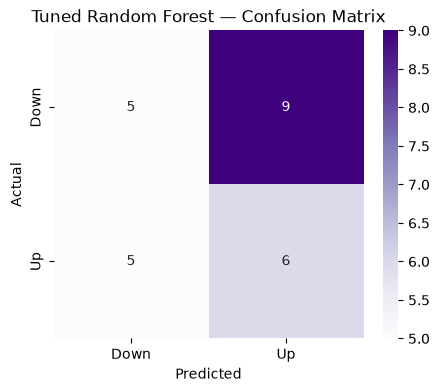

In [24]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Tuned Random Forest — Confusion Matrix')
plt.savefig("../plots_mine/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

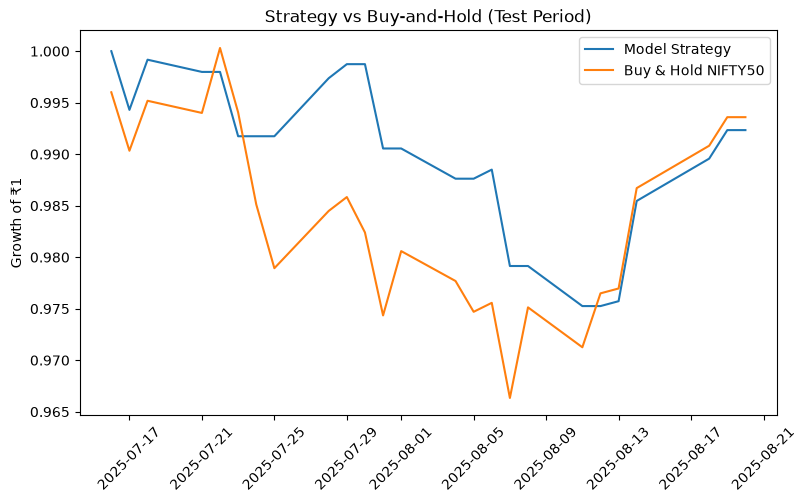

Strategy final:   0.9923
Buy & hold final: 0.9936
Days long: 15 of 25


In [25]:
test_df = ml_df.iloc[split_idx:].copy().reset_index(drop=True)
test_df['pred'] = y_pred_best
test_df['next_day_return_pct'] = (test_df['close'].shift(-1) - test_df['close']) / test_df['close'] * 100
test_df['strategy_return'] = np.where(test_df['pred'] == 1, test_df['next_day_return_pct'], 0)
test_df['cumulative_strategy'] = (1 + test_df['strategy_return'].fillna(0)/100).cumprod()
test_df['cumulative_market']   = (1 + test_df['next_day_return_pct'].fillna(0)/100).cumprod()

plt.figure(figsize=(9,5))
plt.plot(test_df['date'], test_df['cumulative_strategy'], label='Model Strategy')
plt.plot(test_df['date'], test_df['cumulative_market'], label='Buy & Hold NIFTY50')
plt.legend(); plt.title('Strategy vs Buy-and-Hold (Test Period)')
plt.ylabel('Growth of ₹1'); plt.xticks(rotation=45)
plt.savefig("../plots_mine/backtest.png", dpi=300, bbox_inches='tight')
plt.show()

print("Strategy final:  ", round(test_df['cumulative_strategy'].iloc[-1], 4))
print("Buy & hold final:", round(test_df['cumulative_market'].iloc[-1], 4))
print("Days long:", int((test_df['pred']==1).sum()), "of", len(test_df))

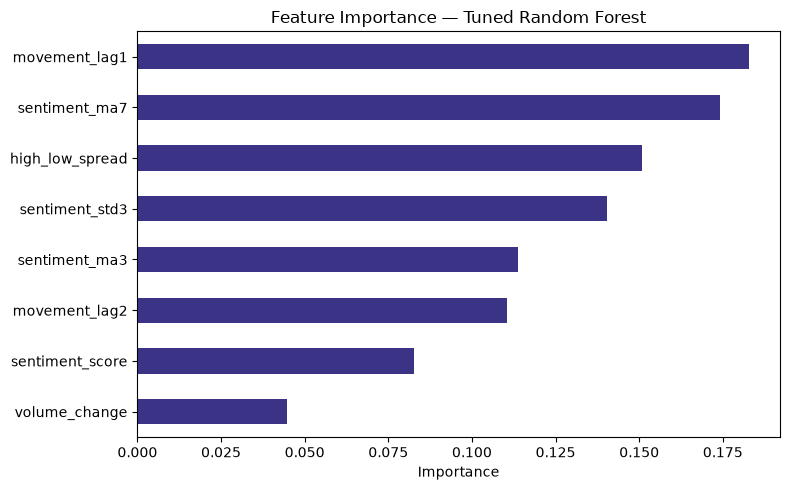

movement_lag1      0.1829
sentiment_ma7      0.1742
high_low_spread    0.1510
sentiment_std3     0.1402
sentiment_ma3      0.1138
movement_lag2      0.1105
sentiment_score    0.0826
volume_change      0.0448
dtype: float64


In [26]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='#3B3486')
plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance'); plt.tight_layout()
plt.savefig("../plots_mine/feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()
print(importances.sort_values(ascending=False).round(4))

## Part B results — next-day prediction

| Model | Test accuracy (25 days) |
|---|---|
| **Majority-class baseline** | **56.00%** |
| Logistic Regression | 44.00% |
| Random Forest | 52.00% |
| XGBoost | 44.00% |
| Tuned Random Forest (GridSearchCV + TimeSeriesSplit, CV 51.25%) | 44.00% |

**No model beats the baseline.** Predicting "down" every single day would have outperformed every model trained here.

**This is the finding, not a failure.** Part A reached 59.85% on *same-day* direction against a 50.76% baseline; the moment the target is shifted forward one trading day, all predictive power disappears. That contrast is the direct answer to the project's central question: news sentiment **co-moves** with same-day market direction but does **not forecast** next-day direction. This is consistent with the efficient-market view that publicly available news is absorbed into prices almost immediately.

Supporting observations:

- **Complexity does not help.** XGBoost, the most expressive model, ties for worst. With 100 training days and 8 features, added capacity fits noise.
- **The tuner agrees.** GridSearchCV selected the most constrained configuration available in the grid (`max_depth=3`, `min_samples_leaf=20`, `n_estimators=100`) with a CV accuracy of 51.25% — regularising as hard as the grid allows is what a model does when there is no signal to fit.
- **Tuning made test accuracy worse** (52.00% → 44.00%). When validation performance is noise, optimising against it does not generalise.
- **A single 25-day test window is not enough evidence.** A 12-point gap here is roughly three days. The walk-forward check below tests the same conclusion across five independent time windows.

### Walk-forward validation (5 independent windows)

| Model | Fold accuracies | Mean |
|---|---|---|
| Random Forest | 0.50, 0.50, 0.55, 0.50, 0.50 | **51.00%** |
| Logistic Regression | 0.65, 0.50, 0.45, 0.60, 0.40 | **52.00%** |
| Per-fold majority baseline | 50, 50, 60, 55, 55 | **54.00%** |

Both models sit below the average baseline across five separate time windows, so the single-split result was not an unlucky window. The Random Forest is essentially pinned at 50% in four of five folds — the behaviour of a model with nothing to learn.

### Confusion matrix (tuned Random Forest)

Of 14 actual down days the model identified only 5, and it predicted "up" on 15 of 25 days. Precision on both classes sits near 0.4–0.5, i.e. coin-flip territory.

### Feature importance

| Feature | Importance |
|---|---|
| movement_lag1 | 0.1829 |
| sentiment_ma7 | 0.1742 |
| high_low_spread | 0.1510 |
| sentiment_std3 | 0.1402 |
| sentiment_ma3 | 0.1138 |
| movement_lag2 | 0.1105 |
| sentiment_score | 0.0826 |
| volume_change | 0.0448 |

The four sentiment features total **0.511** and the four price/volume features **0.489** — effectively a dead heat, so sentiment is not simply being outranked by price history. Within the sentiment group, however, raw `sentiment_score` ranks **seventh of eight** while the smoothed `sentiment_ma7` ranks second. Whatever information the sentiment signal carries survives averaging and is destroyed by daily noise, which matches the Part A finding that the raw score is volume-inflated and mechanically biased.

**Important caveat:** these importances describe what the model split on, not what predicts the market. A model that fails to beat its own baseline cannot support causal claims about its features. This ranking is descriptive only.

### Backtest

Strategy final value **₹0.9923** vs buy-and-hold **₹0.9936** on ₹1, going long on 15 of 25 days. Both lost money; the test window was a declining market. The strategy tracked *above* buy-and-hold through late July and early August purely because it sat in cash during drawdowns, then converged at the end. That is not skill — a model at 44% accuracy cannot be timing anything. The apparent mid-window outperformance is exactly the kind of artefact a 25-day backtest produces.

This backtest excludes transaction costs, slippage and taxes. It is an illustrative exercise, not a trading signal.

Two further caveats. First, the model predicts **intraday** direction (close minus open on day t+1), but the backtest realises **close-to-close** returns, which include the overnight gap — the predicted quantity and the traded quantity are not the same, so even a perfectly accurate classifier would not necessarily produce the returns shown. Second, `close.shift(-1)` leaves the final test day undefined and it is filled with zero, so the simulation covers 24 return transitions rather than 25.

### Conclusion

Financial news sentiment co-moves with same-day NIFTY50 direction (59.85% vs a 50.76% baseline) but carries no next-day forecasting power (every model below a 56% baseline, confirmed across five walk-forward windows). Reported as found.

# Part C — Does a better sentiment measure change the answer?

Part A identified three mechanical flaws in the rule-based scorer. Part C fixes each one, compares against two off-the-shelf sentiment libraries, and re-tests the Part B conclusion. The question: is the weak result a property of the market, or an artefact of a crude scorer?

In [27]:
def sentiment_joined(titles):
    text = ' '.join(titles).lower()
    score = 0
    for word in positive_words: score += text.count(word)
    for word in negative_words: score -= text.count(word)
    return score

merged['score_joined'] = merged['Title'].apply(sentiment_joined)
print("Identical to original:", (merged['score_joined'] == merged['sentiment_score']).all())
print("Days differing:", (merged['score_joined'] != merged['sentiment_score']).sum())

Identical to original: True
Days differing: 0


In [28]:
import re

pos_patterns = [re.compile(r'\b' + re.escape(w) + r'\b') for w in positive_words]
neg_patterns = [re.compile(r'\b' + re.escape(w) + r'\b') for w in negative_words]

def sentiment_regex(titles):
    text = ' '.join(titles).lower()
    return sum(len(p.findall(text)) for p in pos_patterns) - sum(len(p.findall(text)) for p in neg_patterns)

merged['score_regex'] = merged['Title'].apply(sentiment_regex)

# audit: which terms were matching things they shouldn't?
corpus = ' '.join([h for lst in merged['Title'] for h in lst]).lower()
audit = []
for w in set(positive_words) | set(negative_words):
    sub = corpus.count(w)
    wb  = len(re.findall(r'\b' + re.escape(w) + r'\b', corpus))
    if sub - wb > 0:
        audit.append((w, 'POS' if w in positive_words else 'NEG', sub, wb, sub - wb))

audit = pd.DataFrame(audit, columns=['term','list','substring','word_bounded','phantom'])
print(audit.sort_values('phantom', ascending=False).head(10).to_string(index=False))
print("\nPhantom POS:", audit[audit.list=='POS'].phantom.sum(),
      "| Phantom NEG:", audit[audit.list=='NEG'].phantom.sum())

     term list  substring  word_bounded  phantom
      ban  NEG        378             0      378
     gain  POS        268           117      151
     fall  NEG        375           245      130
      low  NEG        144            34      110
     lose  NEG        106             1      105
     rise  POS        351           257       94
    loser  NEG         93             4       89
   gainer  POS         77             8       69
   invest  POS         70             6       64
top loser  NEG         64             2       62

Phantom POS: 841 | Phantom NEG: 1255


In [29]:
merged['n_headlines'] = merged['Title'].apply(len)
merged['score_norm'] = merged['score_regex'] / merged['n_headlines']
print(merged[['sentiment_score','score_regex','score_norm','n_headlines']].describe().round(3))

       sentiment_score  score_regex  score_norm  n_headlines
count          132.000      132.000     132.000      132.000
mean            18.167       21.303       0.852       24.720
std             22.538       20.514       0.616       17.663
min            -24.000      -12.000      -1.091        2.000
25%              4.000        7.000       0.458       12.000
50%             13.000       14.500       0.833       18.000
75%             31.250       34.250       1.300       34.500
max             88.000       85.000       2.500       75.000


In [30]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

vader = SentimentIntensityAnalyzer()
merged['score_vader']    = merged['Title'].apply(lambda L: np.mean([vader.polarity_scores(h)['compound'] for h in L]))
merged['score_textblob'] = merged['Title'].apply(lambda L: np.mean([TextBlob(h).sentiment.polarity for h in L]))
print(merged[['score_vader','score_textblob']].describe().round(4))

       score_vader  score_textblob
count     132.0000        132.0000
mean        0.1903          0.0242
std         0.0990          0.0501
min        -0.1905         -0.1375
25%         0.1282         -0.0032
50%         0.1963          0.0207
75%         0.2487          0.0456
max         0.5134          0.2306


In [31]:
baseline_a = (merged['target'] == merged['target'].mode()[0]).mean()
print(f"Majority baseline: {baseline_a*100:.2f}%\n")
print(f"{'variant':<22}{'corr':>9}{'same-day acc':>15}{'UP calls':>10}")

for col, label in [('sentiment_score','original (substring)'), ('score_joined',"' '.join()"),
                   ('score_regex','regex word-bound'), ('score_norm','regex + normalised'),
                   ('score_vader','VADER'), ('score_textblob','TextBlob')]:
    corr = merged[col].corr(merged['movement'])
    pred = (merged[col] > 0).astype(int)
    acc  = (pred == merged['target']).mean()
    print(f"{label:<22}{corr:>9.4f}{acc*100:>14.2f}%{pred.sum():>10}")

Majority baseline: 50.76%

variant                    corr   same-day acc  UP calls
original (substring)     0.0943         59.85%       106
' '.join()               0.0943         59.85%       106
regex word-bound         0.0429         53.03%       119
regex + normalised       0.1438         53.03%       119
VADER                   -0.1170         46.97%       129
TextBlob                 0.0132         50.00%        95


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

mlc = merged.sort_values('date').reset_index(drop=True).copy()
mlc['next_day_target'] = mlc['target'].shift(-1)
mlc = mlc.dropna(subset=['next_day_target'])
mlc['next_day_target'] = mlc['next_day_target'].astype(int)

for col, tag in [('sentiment_score','orig'), ('score_norm','norm'), ('score_vader','vader')]:
    mlc[f'{tag}_ma3']  = mlc[col].rolling(3).mean()
    mlc[f'{tag}_ma7']  = mlc[col].rolling(7).mean()
    mlc[f'{tag}_std3'] = mlc[col].rolling(3).std()

mlc['movement_lag1']   = mlc['movement'].shift(1)
mlc['movement_lag2']   = mlc['movement'].shift(2)
mlc['volume_change']   = mlc['shares_traded'].pct_change()
mlc['high_low_spread'] = (mlc['high'] - mlc['low']) / mlc['open'] * 100

price_cols = ['movement_lag1','movement_lag2','volume_change','high_low_spread']
all_feats  = ['orig_ma3','orig_ma7','orig_std3','norm_ma3','norm_ma7','norm_std3',
              'vader_ma3','vader_ma7','vader_std3'] + price_cols
mlc = mlc.dropna(subset=all_feats).reset_index(drop=True)

si = int(len(mlc) * 0.8)
yc = mlc['next_day_target']
yc_tr, yc_te = yc.iloc[:si], yc.iloc[si:]
print(f"n = {len(mlc)} | train {si} | test {len(mlc)-si} | baseline {(yc_te == yc_te.mode()[0]).mean()*100:.2f}%\n")

sets = {
    'original sentiment': ['sentiment_score','orig_ma3','orig_ma7','orig_std3'] + price_cols,
    'regex + normalised': ['score_norm','norm_ma3','norm_ma7','norm_std3'] + price_cols,
    'VADER':              ['score_vader','vader_ma3','vader_ma7','vader_std3'] + price_cols,
    'price only':         price_cols,
}

for name, fc in sets.items():
    Xc = mlc[fc]
    Xc_tr, Xc_te = Xc.iloc[:si], Xc.iloc[si:]
    rf_c = RandomForestClassifier(n_estimators=300, max_depth=5,
                                  min_samples_leaf=10, random_state=42).fit(Xc_tr, yc_tr)
    lr_c = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xc_tr, yc_tr)
    print(f"{name:<22} RF {accuracy_score(yc_te, rf_c.predict(Xc_te))*100:>6.2f}%"
          f" | LogReg {accuracy_score(yc_te, lr_c.predict(Xc_te))*100:>6.2f}%")

n = 125 | train 100 | test 25 | baseline 56.00%

original sentiment     RF  52.00% | LogReg  44.00%
regex + normalised     RF  28.00% | LogReg  36.00%
VADER                  RF  52.00% | LogReg  44.00%
price only             RF  44.00% | LogReg  48.00%


## Part C conclusion

Three targeted fixes to the sentiment scorer, plus two off-the-shelf alternatives, tested against the same baselines used in Parts A and B.

**The `' '.join()` stretch goal changes nothing.** Scores are identical on all 132 days (0 days differing), because `.count()` matches substrings and the brackets, quotes and commas that `str(list)` introduces never fall inside a vocabulary term. They pad the string without creating or destroying a match.

**Substring matching was severely contaminated.** Auditing every vocabulary term against a word-boundary regex found **841 phantom positive** and **1,255 phantom negative** matches. The worst offender by a wide margin is `'ban'`: 378 hits in the corpus, **zero** of them as an actual word — every one sits inside "bank", "banks" or "banking", scored as negative news in a corpus dominated by banking coverage. `'fall'` (130 phantom, mostly "fallout"/"falling short"), `'low'` (110, inside "below"/"slowdown"/"follow") and `'lose'` (105, inside "close"/"closed") follow the same pattern. The audit was run on the merged corpus rather than the raw news file, so it reflects only headlines that actually entered the scoring.

### Comparison of sentiment variants (same-day, 132 days, baseline 50.76%)

| Variant | Correlation with movement | Accuracy | UP calls |
|---|---|---|---|
| original (substring) | 0.0943 | 59.85% | 106 |
| `' '.join()` | 0.0943 | 59.85% | 106 |
| regex word-bounded | 0.0429 | 53.03% | 119 |
| regex + normalised | **0.1438** | 53.03% | 119 |
| VADER | −0.1170 | 46.97% | 129 |
| TextBlob | 0.0132 | 50.00% | 95 |

**Fixing the scorer lowered same-day accuracy** from 59.85% to 53.03% — the opposite of the expected result, and the most informative finding in the project.

**The mechanism is visible in the score distributions.** Word-boundary matching raised the minimum score from −24 to −12 and cut DOWN calls from 26 days to 13. Part A's edge was concentrated in exactly those strongly-negative days: 77% correct on 26 DOWN calls versus 56% on 106 UP calls. The 1,255 phantom negative matches — overwhelmingly `'ban'` inside "banking" — were manufacturing that negativity in a banking-dominated corpus. Removing the artefact removed the edge, which is direct evidence that Part A's apparent skill was a scoring bug rather than genuine sentiment detection.

**Normalising by headline count produced the strongest correlation of any variant** (0.144 vs 0.094 for the original), while accuracy stayed flat at 53.03%. Removing the volume bias improves the *shape* of the distribution, but a fixed `> 0` threshold cannot exploit that; a tuned threshold or a model would be needed.

**VADER scores below chance** (46.97%, correlation −0.117). It is trained on social-media text where terms such as "bank", "cut", "yield" and "share" carry different valence than in financial reporting. This is the practical case for a domain-specific model such as FinBERT over a general-purpose sentiment tool.

### Does any variant rescue the next-day model?

| Feature set | Random Forest | Logistic Regression |
|---|---|---|
| **Majority-class baseline** | **56.00%** | **56.00%** |
| original sentiment | 52.00% | 44.00% |
| regex + normalised | 28.00% | 36.00% |
| VADER | 52.00% | 44.00% |
| price only (no sentiment) | 44.00% | 48.00% |

**No.** No sentiment variant beats the baseline, and removing sentiment entirely does not help either — a price-only feature set performs no better. The binding constraint is the data (125 usable rows, a 25-day test window), not the sentiment measure. The Part B conclusion stands: news sentiment co-moves with same-day market direction but does not forecast next-day direction.